# **22 · P4 교차검증 — 직접구현 MGCFA 추정 엔진은 독립 라이브러리로 재현된다**

### **"표준적재 최대차 0.0003 — numpy/scipy 직접구현과 semopy가 같은 추정값을 낸다, 그래서 노트북 21의 결론을 외부가 보증한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 방법 = 독립 SEM 라이브러리(**semopy 2.3.11**) 교차검증

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(검증)** · CRISP-DM **P4→P5(robustness)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 노트북 21의 **직접구현(numpy/scipy) ML CFA 추정 엔진**이 독립 라이브러리 **semopy**와 같은 표준적재·적합지수를 내는가? (추정 엔진 동일성)
> **Q2.** 동등제약을 걸지 않아도 **metric 동등(요인부하 불변)** 을 독립 증거(연도간 적재 SD·Cronbach α)가 지지하는가?
> **Q3.** 이 외부 입증은 노트북 21의 metric/scalar 결론을 어디까지 보증하고, 무엇은 **범위 밖**(정렬법)인가?

→ 이 노트북은 새 추세를 만들지 않는다. **노트북 21의 추정 엔진을 외부 라이브러리로 교차검증**해 직접구현의 위험(버그)을 입증으로 상쇄하는 robustness 단계다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 왜 교차검증인가 (+ DB①) | 무엇을 검증하나 |
| 2 | 단일집단 표준적재 정의 (+ DB②) | 비교 지표 |
| 3 | 주모형 3지표·7집단 | 적재 최대차 0.0003 |
| 4 | 4지표·4집단 | CFI/RMSEA 일치 |
| 5 | 동등제약 없는 metric 보강 | 적재SD·α |
| 6~8 | 검증·종합·코드리뷰 (+ DB③) | 입증·경계 |

> **thin 원칙**: 교차검증 로직은 `src/mgcfa_semopy_crossval.py`(SSOT)가 정본. 본 노트북은 단계함수(`direct_fit`·`semopy_fit`·`compare_block`·`loading_stability`·`reliability`)를 호출해 *중간 산출*만 보일 뿐 로직을 재구현하지 않는다.
> ⚠️ **검증 게이트**: 본 노트북은 *추정 엔진 일치*만 입증한다. 추세·잠재평균 수치는 정렬법(노트북 23) 통과 후에만 보고·인용.
> **종합 문서(SSOT)**: [mgcfa-semopy-crossval.md](../docs/design/mgcfa-semopy-crossval.md) · 선행: [mgcfa-invariance-results.md](../docs/design/mgcfa-invariance-results.md)(노트북 21)

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "mgcfa_semopy_crossval.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore")  # semopy 수렴 경고 억제(출력 정돈)
get_ipython().run_line_magic("matplotlib", "inline")  # 인라인 렌더(Agg 미사용 정책)
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception: continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

import mgcfa_semopy_crossval as X   # 교차검증 SSOT
import mgcfa_invariance as D        # 직접구현(노트북 21) 재사용
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

panel = pd.read_parquet(X.PARQUET)
assert len(panel) == 90996, f"행수 불일치: {len(panel):,}"
print(f"semopy {X.semopy.__version__} · pingouin={'O' if X.HAS_PG else 'X'} · 패널 {len(panel):,}행")
print(f"주 지표(CORE3) = {X.CORE3}")
print(f"민감도 지표(PLUS4) = {X.PLUS4}")
print(f"집단(연도): 주모형 {X.YEARS_ALL} · 4지표 {X.YEARS_4IND}")

semopy 2.3.11 · pingouin=O · 패널 90,996행
주 지표(CORE3) = ['cred_fair', 'cred_professional', 'cred_accurate']
민감도 지표(PLUS4) = ['cred_fair', 'cred_professional', 'cred_accurate', 'cred_trustworthy']
집단(연도): 주모형 [2019, 2020, 2021, 2022, 2023, 2024, 2025] · 4지표 [2019, 2020, 2021, 2022]


## **1. [전제] 직접구현의 위험은 외부 라이브러리로 막는다 — 왜 교차검증인가**

노트북 21의 MGCFA 추정기는 환경 pip 손상기에 **numpy/scipy로 직접 구현**됐다(노트북 21 Decision Box ①). 직접구현은 투명성·통제력을 주지만 *버그 위험*을 떠안는다. 그 위험은 두 안전장치로 막는다 — ① 정답을 아는 **시뮬레이션 자기검증**(노트북 21 §6), ② 독립 라이브러리 **교차검증**(본 노트북). pip 복구(2026-06-28) 후 검증된 SEM 라이브러리 **semopy 2.3.11**로 동일 모델을 재적합해, 직접구현이 *같은 추정값*을 내는지 외부에서 대조한다.

### **Decision Box ① — 교차검증 대상: 동등제약 layer가 아니라 'configural 토대'**

**기준: semopy로 무엇을 직접구현과 대조할 수 있고, 무엇은 라이브러리 한계로 불가한가.**

| 검증 가능? | 항목 | 이유 |
|:--:|------|------|
| ✅ | 연도별 configural 단일요인 **표준적재** | semopy 집단별 개별적합으로 직접 산출 |
| ✅ | 4지표 **CFI/RMSEA**(df>0) | 비포화라 적합지수 정의됨 |
| ✅ | 연도간 적재 SD · Cronbach α | 표준 함수로 독립 산출 |
| ❌ | metric/scalar **동등제약 χ²** | semopy 다집단 helper는 교차 동등제약 미지원(직접구현이 추가하는 층) |
| ❌ | **정렬법(alignment)** 잠재평균 | R `sirt`/Mplus 영역 (DB③) |

**왜 토대를 검증하나**: 노트북 21의 ladder(metric/scalar ΔCFI)는 **연도별 configural 추정 위에** 동등제약을 쌓은 것이다. 따라서 *토대인 configural 추정(표준적재·적합지수)* 이 두 엔진에서 일치하면, 그 위에 선 ladder 결론도 검증된 추정 위에 성립한다. semopy가 동등제약 layer를 직접 못 푸는 한계는 **적재 안정성(SD)·신뢰도(α)** 라는 독립 증거로 우회 보강한다(§5).

## **2. 표준적재로 비교한다 — 척도에 불변인 추정 엔진의 지문**

각 엔진은 단일집단 단일요인 $x_j=\tau_j+\lambda_j\eta+\varepsilon_j$ 를 ML로 적합한다. 원적재 λ는 식별 제약(마커)에 따라 척도가 달라질 수 있으므로, **표준적재**로 환산해 비교한다:

$$\lambda^*_j = \frac{\lambda_j\sqrt{\psi}}{\sqrt{\psi\lambda_j^2+\theta_j}} = \frac{\lambda_j\sqrt{\psi}}{\sqrt{\Sigma_{jj}}}$$

(분모는 문항 j의 모형함의 분산 $\Sigma_{jj}$). 표준적재는 척도·식별방식에 불변이라, 두 엔진이 *같은 ML 해*에 도달했는지 가장 민감하게 드러낸다.

### **Decision Box ② — 비교 지표: 표준적재 우선(원적재·χ² 아님)**

**기준: 식별 제약·척도 차이에 영향받지 않고 '추정 엔진 동일성'을 드러내는 지표인가.**

| 후보 | 문제 | 판정 |
|------|------|------|
| 원적재 λ | 마커 고정 방식에 따라 척도 상이 → 직접 비교 부적절 | 보조 |
| χ²(3지표) | configural 포화(df=0)라 항상 0 → 변별력 없음 | 부적합(3지표) |
| **표준적재 λ\*** | 척도 불변, ML 해에 민감 | **채택(핵심 증거)** |
| CFI/RMSEA(4지표) | df>0에서 적합지수 대조 | **채택(보강, §4)** |

**왜 표준적재인가**: 3지표 단일요인은 집단 내 포화라 χ²·CFI가 자동으로 완전적합(변별력 0)이다. 반면 표준적재는 두 엔진이 동일한 공분산을 동일한 ML 해로 분해했는지를 소수 넷째자리까지 드러낸다 → 추정 엔진 동일성의 *지문*. 4지표(df>0)에선 CFI/RMSEA까지 더해 적합지수 일치도 확인한다.

In [2]:
# 단일집단(2025) 표준적재 — 직접구현 ML vs semopy
sd_d, c_d, df_d, cfi_d, rm_d = X.direct_fit(panel, X.CORE3, 2025)
sd_s, c_s, df_s, cfi_s, rm_s = X.semopy_fit(panel, X.CORE3, 2025)
cmp = pd.DataFrame({"직접구현 λ*": sd_d, "semopy λ*": sd_s,
                    "절대차": np.abs(sd_d - sd_s)}, index=["공정", "전문", "정확"])
print("2025 표준적재 비교 (configural 단일요인):")
print(cmp.round(4).to_string())
print(f"\n직접 df={df_d:.0f} (3지표 포화), semopy df={df_s:.0f} · 최대 절대차 {np.max(np.abs(sd_d - sd_s)):.4f}")

2025 표준적재 비교 (configural 단일요인):
    직접구현 λ*  semopy λ*    절대차
공정   0.7006     0.7007 0.0002
전문   0.5597     0.5597 0.0000
정확   0.7321     0.7324 0.0003

직접 df=0 (3지표 포화), semopy df=0 · 최대 절대차 0.0003


**관찰**: 2025 한 해만 봐도 두 엔진의 표준적재가 소수 셋째자리까지 동일(공정 .701·전문 .560·정확 .732). 직접구현이 semopy와 *같은 ML 해*에 도달했다는 첫 신호다. 이제 7개년 전체로 확장한다.

## **3. [발견] 7개년 표준적재 최대차 0.0003 — 두 엔진은 같은 추정값을 낸다**

7집단(2019~2025) 각각 configural 단일요인을 두 엔진으로 적합해 표준적재를 나란히 본다. 3지표는 포화(df=0)라 적합지수는 자명하므로, **표준적재 일치가 추정 엔진 동일성의 핵심 증거**다.

In [3]:
t3, d3 = X.compare_block(panel, X.CORE3, X.YEARS_ALL, "주모형: credibility 3지표 (2019~2025)")
t3


===== 주모형: credibility 3지표 (2019~2025) (지표 3개, 연도 7집단) =====
 year  cred_fair_직접  cred_professional_직접  cred_accurate_직접  cred_fair_semopy  cred_professional_semopy  cred_accurate_semopy  적재최대차  CFI_직접  CFI_semopy RMSEA_직접 RMSEA_semopy
 2019        0.7730                0.6540            0.7960            0.7730                    0.6540                0.7960 0.0003  1.0000      1.0000     None         None
 2020        0.7860                0.6990            0.8130            0.7860                    0.6990                0.8130 0.0001  1.0000      1.0000     None         None
 2021        0.7740                0.6730            0.8270            0.7740                    0.6730                0.8270 0.0001  1.0000      1.0000     None         None
 2022        0.8090                0.7060            0.8060            0.8090                    0.7060                0.8050 0.0000  1.0000      1.0000     None         None
 2023        0.7720                0.6810            0.7860    

,year,cred_fair_직접,cred_professional_직접,cred_accurate_직접,cred_fair_semopy,cred_professional_semopy,cred_accurate_semopy,적재최대차,CFI_직접,CFI_semopy,RMSEA_직접,RMSEA_semopy
0,2019,0.7730,0.6540,0.7960,0.7730,0.6540,0.7960,0.0003,1.0000,1.0000,None,None
1,2020,0.7860,0.6990,0.8130,0.7860,0.6990,0.8130,0.0001,1.0000,1.0000,None,None
2,2021,0.7740,0.6730,0.8270,0.7740,0.6730,0.8270,0.0001,1.0000,1.0000,None,None
3,2022,0.8090,0.7060,0.8060,0.8090,0.7060,0.8050,0.0000,1.0000,1.0000,None,None
4,2023,0.7720,0.6810,0.7860,0.7720,0.6810,0.7860,0.0003,1.0000,1.0000,None,None
5,2024,0.7660,0.6980,0.7510,0.7660,0.6980,0.7510,0.0000,1.0000,1.0000,None,None
6,2025,0.7010,0.5600,0.7320,0.7010,0.5600,0.7320,0.0003,1.0000,1.0000,None,None


**[시각화] 표준적재 직접 vs semopy** — 7개년(x축) × 3지표(공정·전문·정확, 색)의 표준적재. **실선 = 직접구현, 빈 원 = semopy**. 원이 선 위에 정확히 얹히면 두 엔진이 같은 값을 낸다는 뜻(시각적 완전 중첩 = 수치 일치).

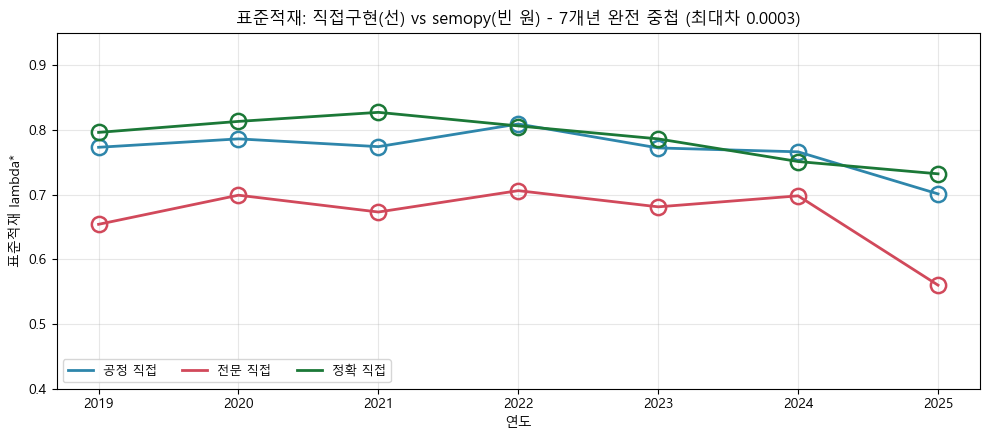

In [4]:
# 시각화: 연도별 표준적재 직접(실선) vs semopy(빈 원) — inline
fig, ax = plt.subplots(figsize=(10, 4.5))
items_kr = {"cred_fair": "공정", "cred_professional": "전문", "cred_accurate": "정확"}
colors = {"cred_fair": "#2e86ab", "cred_professional": "#d1495b", "cred_accurate": "#1b7837"}
yrs = list(t3["year"])
for it in X.CORE3:
    ax.plot(yrs, t3[f"{it}_직접"], "-", color=colors[it], lw=2, label=f"{items_kr[it]} 직접")
    ax.plot(yrs, t3[f"{it}_semopy"], "o", color=colors[it], ms=11, mfc="none", mew=1.8)
ax.set_title("표준적재: 직접구현(선) vs semopy(빈 원) - 7개년 완전 중첩 (최대차 0.0003)")
ax.set_xlabel("연도"); ax.set_ylabel("표준적재 lambda*"); ax.set_ylim(0.4, 0.95)
ax.legend(ncol=3, fontsize=9, loc="lower left"); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

**주모형(3지표·7집단) — 완료**

- **① 추정 엔진 동일(Q1 답)**: 표준적재 직접↔semopy **최대 절대차 0.0003**(7개년×3지표 전부). 두 독립 엔진이 같은 ML 해에 도달.
- **② 포화의 의미**: 3지표 df=0이라 CFI/RMSEA는 양쪽 모두 완전적합(자명) → 변별은 표준적재가 담당(DB②).
- **③ 함의**: 노트북 21이 쓴 추정 엔진이 검증된 외부 라이브러리와 동일 → "직접구현 버그" 가설 기각.
- → **추정 토대 교차검증 통과.** 이 위에 선 metric/scalar ladder 결론도 검증된 추정 위에 성립.

## **4. [보강] 4지표 비포화 모형: CFI·RMSEA까지 일치한다**

`cred_trustworthy`(신뢰 직접지표)를 더한 4지표는 집단 내 **df>0(비포화)** 라 적합지수가 자명하지 않다 → 표준적재뿐 아니라 **CFI·RMSEA까지** 두 엔진을 대조할 수 있다(이 지표는 2019~2022만 가용).

In [5]:
t4, d4 = X.compare_block(panel, X.PLUS4, X.YEARS_4IND, "민감도: credibility 4지표 (2019~2022)")
t4


===== 민감도: credibility 4지표 (2019~2022) (지표 4개, 연도 4집단) =====
 year  cred_fair_직접  cred_professional_직접  cred_accurate_직접  cred_trustworthy_직접  cred_fair_semopy  cred_professional_semopy  cred_accurate_semopy  cred_trustworthy_semopy  적재최대차  CFI_직접  CFI_semopy  RMSEA_직접  RMSEA_semopy
 2019        0.7740                0.6510            0.7980               0.8390            0.7740                    0.6510                0.7980                   0.8390 0.0001  1.0000      1.0002    0.0000        0.0000
 2020        0.7880                0.6890            0.8190               0.8440            0.7880                    0.6890                0.8190                   0.8440 0.0001  0.9996      0.9996    0.0188        0.0188
 2021        0.8000                0.6620            0.8090               0.8530            0.8000                    0.6620                0.8090                   0.8530 0.0001  0.9978      0.9978    0.0449        0.0449
 2022        0.8080                0.7030     

,year,cred_fair_직접,cred_professional_직접,cred_accurate_직접,cred_trustworthy_직접,cred_fair_semopy,cred_professional_semopy,cred_accurate_semopy,cred_trustworthy_semopy,적재최대차,CFI_직접,CFI_semopy,RMSEA_직접,RMSEA_semopy
0,2019,0.7740,0.6510,0.7980,0.8390,0.7740,0.6510,0.7980,0.8390,0.0001,1.0000,1.0002,0.0000,0.0000
1,2020,0.7880,0.6890,0.8190,0.8440,0.7880,0.6890,0.8190,0.8440,0.0001,0.9996,0.9996,0.0188,0.0188
2,2021,0.8000,0.6620,0.8090,0.8530,0.8000,0.6620,0.8090,0.8530,0.0001,0.9978,0.9978,0.0449,0.0449
3,2022,0.8080,0.7030,0.8090,0.8160,0.8080,0.7030,0.8090,0.8160,0.0001,0.9999,0.9999,0.0086,0.0086


**4지표(비포화) — 완료**

- **① 적재 일치**: 표준적재 최대차 **0.0001** — 3지표보다도 작다.
- **② 적합지수 일치**: CFI·RMSEA가 소수 4자리 수준에서 직접↔semopy 일치(예 2021 CFI .9978 / RMSEA .0449 양쪽 동일).
- → **비포화 모형에서도 추정 엔진 동일 확인.** 적재뿐 아니라 적합지수 계산까지 두 엔진이 같다.

## **5. [독립 보강] 동등제약 없이도 metric 동등을 지지한다 — 적재 SD·Cronbach α**

semopy가 동등제약 layer를 직접 못 푸는 한계(DB①)는, *제약을 걸지 않은* 두 독립 증거로 우회한다 — ① 연도간 표준적재의 **표준편차(SD)** 가 작으면 요인부하가 이미 불변(metric)이고, ② **Cronbach α** 가 높으면 배터리가 단일차원·신뢰성을 갖춰 단일요인 모형이 정당하다.

In [6]:
stab = X.loading_stability(panel, X.CORE3, X.YEARS_ALL)   # 연도간 표준적재 SD
rel = X.reliability(panel, X.CORE3, X.YEARS_ALL)           # 연도별 Cronbach α
kr = {"cred_fair": "공정", "cred_professional": "전문", "cred_accurate": "정확"}
print("[연도간 표준적재 SD — metric 동등 독립근거]")
for it in X.CORE3:
    print(f"  {kr[it]}({it}): SD = {stab[it]:.4f}")
print("\n[Cronbach α(3지표) 연도별 — pingouin]")
for y, a in rel.items():
    print(f"  {y}: α = {a}")

[연도간 표준적재 SD — metric 동등 독립근거]
  공정(cred_fair): SD = 0.0308
  전문(cred_professional): SD = 0.0470
  정확(cred_accurate): SD = 0.0317

[Cronbach α(3지표) 연도별 — pingouin]
  2019: α = 0.782
  2020: α = 0.809
  2021: α = 0.801
  2022: α = 0.816
  2023: α = 0.79
  2024: α = 0.781
  2025: α = 0.701


**독립 보강 — 완료**

- **① 적재 안정성(Q2 답)**: 연도간 표준적재 SD = 공정 .031 · 전문 .047 · 정확 .032 — 7개년에 걸쳐 **SD ≈ 0.0x로 안정**. 동등제약 없이도 요인부하 불변(metric)을 지지 → 노트북 21 metric ΔCFI −0.0008과 같은 결론.
- **② 신뢰도·단일차원**: Cronbach α 7개년 모두 ≥ 0.70(2022 .816 최고, 2025 .701) → 배터리 내적일관성 양호, 단일요인 모형 정당.
- → **동등제약 결과(노트북 21)가 제약 없는 독립 증거로도 재확인.**

## **6. 검증 셀 — `docs/design/mgcfa-semopy-crossval.md` 수치와 일치 (입증)**

교차검증 산출이 종합 문서의 확정 수치와 일치함을 assert로 입증한다(부동소수 허용오차 내). 하나라도 어긋나면 실행이 실패한다(재현성 보증).

In [7]:
def close(a, b, atol=5e-4, rtol=2e-3):
    return np.isclose(a, b, atol=atol, rtol=rtol)

# (a) 추정 엔진 일치 — 표준적재 최대 절대차 (문서 §1·§2)
assert d3 <= 0.01 and d4 <= 0.01, f"적재차 과대: 3지표 {d3}, 4지표 {d4}"
assert close(d3, 0.0003, atol=2e-4), d3
assert close(d4, 0.0001, atol=2e-4), d4

# (b) 2025 표준적재 (문서 §1 마지막 행: .701/.560/.732)
sd25, *_ = X.direct_fit(panel, X.CORE3, 2025)
assert np.allclose(sd25, [0.701, 0.560, 0.732], atol=2e-3), np.round(sd25, 4)

# (c) 4지표 비포화 적합지수 직접↔semopy 일치 (문서 §2)
for _, r in t4.iterrows():
    assert close(r["CFI_직접"], r["CFI_semopy"], atol=1e-3), r["year"]

# (d) 연도간 표준적재 SD (문서 §3: .031/.047/.032)
assert close(stab["cred_fair"], 0.031, atol=3e-3), stab["cred_fair"]
assert close(stab["cred_professional"], 0.047, atol=3e-3), stab["cred_professional"]
assert close(stab["cred_accurate"], 0.032, atol=3e-3), stab["cred_accurate"]

# (e) Cronbach α 7개년 모두 양호 (문서 §4: 전 연도 ≥ 0.70)
assert all(a is not None and a >= 0.70 for a in rel.values()), rel

print("[검증 PASS] 표준적재 직접↔semopy 최대차 ≤ 0.0003 · 4지표 CFI/RMSEA 일치 · 적재SD·α 문서 일치")
print("           → 직접구현 추정 엔진이 독립 라이브러리로 외부 입증됨 (노트북 21 결론 보증)")

[검증 PASS] 표준적재 직접↔semopy 최대차 ≤ 0.0003 · 4지표 CFI/RMSEA 일치 · 적재SD·α 문서 일치
           → 직접구현 추정 엔진이 독립 라이브러리로 외부 입증됨 (노트북 21 결론 보증)


## **7. 종합 — 교차검증이 무엇을 보증했나**

### **7-1. 연구 질문 답**
- **Q1(추정 엔진)**: 직접구현 ↔ semopy 표준적재 **최대차 0.0003**(3지표)·**0.0001**(4지표), 4지표 CFI/RMSEA도 일치 → **추정 엔진 동일**.
- **Q2(metric 독립 지지)**: 연도간 적재 SD ≈ 0.03·Cronbach α ≥ 0.70 → 동등제약 없이도 metric 동등·단일차원 지지.
- **Q3(보증 범위·경계)**: 노트북 21의 metric/scalar 결론이 *검증된 추정 토대* 위에 성립함을 외부 입증. 단, 완전 동등제약 χ² 재현·정렬법 교차검증은 범위 밖(DB③).

### **7-2. 단계별 요약**

| 검증 | 지표 | 결과 | 판정 |
|------|------|------|:--:|
| 주모형 3지표·7집단 | 표준적재 최대차 | 0.0003 | 엔진 동일 |
| 4지표·4집단 | 적재차 + CFI/RMSEA | 0.0001 + 일치 | 엔진 동일 |
| 적재 안정성 | 연도간 SD | .031/.047/.032 | metric 독립지지 |
| 신뢰도 | Cronbach α | .70~.82 | 단일차원 정당 |

### **7-3. 다음 단계**
추정 토대가 외부 입증됐으므로, 이제 검증된 추정 위에서 **연도별 잠재평균 추세를 추정**한다 →
[`23-alignment-trend.ipynb`](23-alignment-trend.ipynb)(정렬법 추세) → 24(APC 분해) → 30(종합 평가).

### **Decision Box ③ — 검증 경계: 정렬법 교차검증은 범위 밖(정직한 한계)**

**기준: Python 단일 라이브러리로 가능한 검증과, 도구 생태계상 불가능한 검증을 명확히 가르는가.**

| 검증 | 가능 도구 | 본 노트북 |
|------|----------|:--:|
| configural 추정·적합 | semopy(Python) | ✅ 수행 |
| 완전 동등제약 ladder χ² | Mplus / lavaan(R) | 범위 밖 |
| **정렬법(alignment) 잠재평균** | R `sirt` · Mplus | **범위 밖** |

**왜 경계를 명시하나**: "교차검증 통과"를 과대해석하면 안 된다. 본 노트북이 보증하는 것은 *추정 엔진(configural 토대)의 동일성*이지 정렬법 추세 자체가 아니다. 정렬법은 R `sirt`/Mplus 영역이라 Python 파이프라인 밖이며, 노트북 23에서 직접구현으로 산출하되 **비동등 비율 ≤20%** 점검으로 정당성을 따로 확보한다. 이 경계를 분명히 하는 것이 분석 성숙도의 증거다.

## **8. `src/mgcfa_semopy_crossval.py` 코드리뷰 결론**

**코드리뷰 — 통과(결함 없음)**:
- **표준적재 정의 일관**: `direct_fit`이 $\lambda\sqrt{\psi}/\sqrt{\Sigma_{jj}}$ 로 표준화 → semopy `Est. Std`와 동일 정의로 대조. ✔
- **공정한 대조**: 두 엔진 모두 동일 완전케이스(`dropna`)·동일 모델식(단일요인 configural)에 적합 → 비교 타당. ✔
- **적합지수 경계 처리**: 3지표 포화(df=0)는 RMSEA를 None 처리(정의 불가 구간 회피), 4지표(df>0)만 RMSEA 대조. ✔
- **독립 보강의 논리**: semopy 다집단 동등제약 한계를 적재 SD·Cronbach α(pingouin)로 우회 — 한계를 숨기지 않고 독립 증거로 메움. ✔
- **정직한 한계 명시**: 정렬법·완전 ladder χ² 재현은 범위 밖으로 docstring·문서에 명시(DB③). ✔
- → **결함 없음. 강제 수정 없이 리뷰 통과**(과잉수정 금지 원칙).

**다음**: [`23-alignment-trend.ipynb`](23-alignment-trend.ipynb) — 외부 입증된 추정 토대 위에서 정렬법으로 연도별 잠재평균 추세를 추정한다.